In [1]:
import argparse
import os

import pandas as pd
import pickle
from tqdm import tqdm
from copy import deepcopy

import numpy as np
import torch
from torch import optim
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import sys

In [2]:
# top r svd
def top_r_svd(A, r):
    V, S, Vt = torch.linalg.svd(A, full_matrices=True)

    Vr = V[:, :r]  
    Sr = S[:r]   
    Vtr = Vt[:r, :]
    return Vr, Sr, Vtr

# norm by dividing the max singular value
def svd_norm(A):
    U, S, V = torch.svd(A)

    S_normalized = S / S.max()
    scale = S.max()

    A_normalized = U @ torch.diag(S_normalized) @ V.t()

    return A_normalized, scale

# norm by UV
def uv_norm(A):
    U, S, V = torch.svd(A)

    A_normalized = U @ V.t()

    return A_normalized

# reverse norm by multipying the max singular value
def svd_norm_reverse(A, scale):
    U, S, V = torch.svd(A)

    S_reverse = S * scale

    A_normalized = U @ torch.diag(S_reverse) @ V.t()

    return A_normalized

In [33]:
d1 = 300
r = 2
d2 = 10

mat1 = torch.randn(d1, 2)
mat2 = torch.randn(2, d2)
M = mat1 @ mat2

# r = mat2.shape[0]


p_prime = 0.75
p = 1 - p_prime
noise = 0.00
dataset = 'random'


norm of M: 165.3603973388672


  0%|          | 0/5000 [00:00<?, ?it/s, In epoch 16, loss: 11224413.000)]

100%|██████████| 5000/5000 [00:11<00:00, 435.41it/s, In epoch 4999, loss: 669943.938)] 


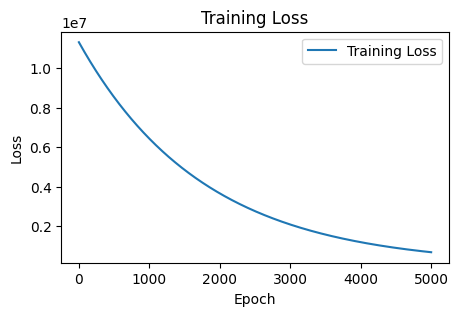

In [17]:
"""
Train for X
"""
# observed M & norm
mask = torch.bernoulli(torch.full((M.shape[0],), p)).bool()
observed_M = deepcopy(M)
observed_M[mask] = 0 # mask user
#observed_M = M
#observed_M_norm, scale_M = svd_norm(observed_M) # svd norm
MTM = observed_M.t() @ observed_M


scale_diag = (p_prime - 1) / (p_prime ** 2) * torch.diag(MTM).diag() # objective matrix
A = scale_diag + 1 / (p_prime ** 2) * MTM

print(f"norm of M: {torch.norm(M)}")

# parameters setting
d1, d2 = observed_M.shape
X = torch.randn(d2, d2, requires_grad=True)
#X = torch.tensor(MTM, requires_grad=True)

epochs = 5000
alpha = 0.05

loop = tqdm(range(epochs))
eta = 1 / np.sqrt(epochs)
optimizer = optim.SGD([X], lr=eta)

# opt
train_losses = []
writer = SummaryWriter('runs/'+dataset)
for i in loop:
    loss = ((X - A)**2).mean() # mse loss
    U, D, Vt = torch.linalg.svd(X, full_matrices=False)
    loss.backward()

    noise_matrix = torch.normal(mean=0, std=noise, size=(d2, d2))

    X.grad = X.grad + alpha * U @ Vt + noise_matrix # alg
    """
    with torch.no_grad():
        X.data += -eta*X.grad
    """
    optimizer.step()
    X.grad.zero_()
    #print(loss.item())
    writer.add_scalar('Loss', loss.item(), i)
    train_losses.append(loss.item())
    loop.set_postfix_str('In epoch {}, loss: {:.3f})'.format(i, loss.item()))

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()



In [18]:
"""
normalization for result
"""
#X, _ = svd_norm(X)
u, d, vt = torch.linalg.svd(X)
#X = vt.t() @ vt

err = X - M.T @ M

#print(f"x - mtm: {X - M.T @ M}")

print(torch.norm(err), torch.norm(M.T @ M))

#print(f"norm of X: {torch.norm(X)}")
#print(f"norm of M: {torch.norm(M.T @ M)}")


tensor(3389.4263, grad_fn=<LinalgVectorNormBackward0>) tensor(27344.0859)


In the case r=1, use every column to recover M independently. If M can be retrieved, the result should be similar in every column.

In [34]:
"""
recover M
"""
_, S, item_vector = top_r_svd(M.t() @ M, r)
predict_matrix = []
miss_item_u = []
print(M.shape)
for i in range(5):
    M_u = M[i] # get objective row

    #print(f"M_u: {M_u}")
    #print(f"item_vector: {item_vector}")
    print(f"user_value: {M_u/item_vector}")
    print()



torch.Size([300, 10])
user_value: tensor([[-13.2294, -65.1922,  -0.8258,  -3.9994, -12.6415,  -0.4763,  13.1555,
           2.3633,   0.1903,  12.2572],
        [ -3.7686,  -3.6928,  -6.1445,  -4.0066,  -3.7731, -12.1301,  -3.5836,
          -3.2214,  -1.3384,  -3.5771]])

user_value: tensor([[  7.6812,  47.4558,  -1.8130,   0.6162,   7.2312,  -2.0805, -12.5149,
          -4.2541,  -2.5907, -11.8273],
        [  2.1881,   2.6881, -13.4900,   0.6173,   2.1583, -52.9881,   3.4091,
           5.7987,  18.2242,   3.4516]])

user_value: tensor([[ -4.0181, -24.7394,   0.9281,  -0.3374,  -3.7837,   1.0675,   6.5035,
           2.1998,   1.3333,   6.1452],
        [ -1.1446,  -1.4014,   6.9058,  -0.3381,  -1.1293,  27.1873,  -1.7715,
          -2.9986,  -9.3788,  -1.7934]])

user_value: tensor([[ -2.2045,  -8.0157,  -0.8174,  -1.1723,  -2.1388,  -0.7783,   0.7462,
          -0.4607,  -0.7037,   0.6458],
        [ -0.6280,  -0.4541,  -6.0817,  -1.1744,  -0.6384, -19.8212,  -0.2033,
           0

In [7]:
mat1 = torch.randn(100, 1)
mat2 = torch.randn(1, 3)
m = mat1 @ mat2

u, d, vt = torch.linalg.svd(mat2)
print(d)
print(vt)
#m = vt.t() @ vt # norm the highest singular value to 1?

u, d, vt = top_r_svd(m, r=1)
vt = vt / torch.norm(vt, p=2)

print(f"mat2: {mat2}")
print(f"vt: {vt}")

u, d, vt = torch.linalg.svd(m)
print(vt)
print(d)

tensor([1.4783])
tensor([[-0.3603,  0.9292, -0.0828],
        [ 0.9292,  0.3653,  0.0565],
        [-0.0828,  0.0565,  0.9950]])
mat2: tensor([[ 0.5326, -1.3736,  0.1223]])
vt: tensor([[-0.3603,  0.9292, -0.0828]])
tensor([[-0.3603,  0.9292, -0.0828],
        [ 0.9328,  0.3582, -0.0396],
        [-0.0071, -0.0914, -0.9958]])
tensor([1.3616e+01, 5.4302e-07, 3.9575e-08])


In [8]:
X

tensor([[ 6.2470e-02,  6.1339e+00,  3.8559e+00, -5.2493e+00, -4.3360e-01,
          6.9880e+00, -5.4974e+00, -1.3505e+00,  2.3029e+00, -1.0281e+00],
        [ 6.1339e+00,  4.9315e+02,  3.9169e+02, -5.3346e+02, -4.2838e+01,
          7.1032e+02, -5.5872e+02, -1.3626e+02,  2.3354e+02, -1.0312e+02],
        [ 3.8559e+00,  3.9169e+02,  1.9579e+02, -3.3515e+02, -2.6923e+01,
          4.4626e+02, -3.5102e+02, -8.5608e+01,  1.4672e+02, -6.4788e+01],
        [-5.2492e+00, -5.3346e+02, -3.3515e+02,  3.6156e+02,  3.6658e+01,
         -6.0778e+02,  4.7807e+02,  1.1659e+02, -1.9983e+02,  8.8238e+01],
        [-4.3363e-01, -4.2838e+01, -2.6923e+01,  3.6658e+01,  3.0255e+00,
         -4.8804e+01,  3.8392e+01,  9.4112e+00, -1.6070e+01,  7.1580e+00],
        [ 6.9879e+00,  7.1032e+02,  4.4626e+02, -6.0778e+02, -4.8804e+01,
          6.3957e+02, -6.3656e+02, -1.5525e+02,  2.6607e+02, -1.1749e+02],
        [-5.4975e+00, -5.5872e+02, -3.5102e+02,  4.7807e+02,  3.8392e+01,
         -6.3656e+02,  3.9643e+0

In [9]:
M.T @ M

tensor([[ 5.7541e-02,  5.8504e+00,  3.6757e+00, -5.0059e+00, -4.0191e-01,
          6.6653e+00, -5.2430e+00, -1.2787e+00,  2.1916e+00, -9.6775e-01],
        [ 5.8504e+00,  5.9482e+02,  3.7371e+02, -5.0896e+02, -4.0863e+01,
          6.7768e+02, -5.3306e+02, -1.3001e+02,  2.2282e+02, -9.8393e+01],
        [ 3.6757e+00,  3.7371e+02,  2.3480e+02, -3.1977e+02, -2.5674e+01,
          4.2577e+02, -3.3491e+02, -8.1683e+01,  1.3999e+02, -6.1818e+01],
        [-5.0059e+00, -5.0896e+02, -3.1977e+02,  4.3550e+02,  3.4965e+01,
         -5.7986e+02,  4.5612e+02,  1.1125e+02, -1.9066e+02,  8.4191e+01],
        [-4.0191e-01, -4.0863e+01, -2.5674e+01,  3.4965e+01,  2.8072e+00,
         -4.6555e+01,  3.6621e+01,  8.9316e+00, -1.5308e+01,  6.7595e+00],
        [ 6.6653e+00,  6.7768e+02,  4.2577e+02, -5.7986e+02, -4.6555e+01,
          7.7208e+02, -6.0732e+02, -1.4812e+02,  2.5386e+02, -1.1210e+02],
        [-5.2430e+00, -5.3306e+02, -3.3491e+02,  4.5612e+02,  3.6621e+01,
         -6.0732e+02,  4.7772e+0

In [10]:
A

tensor([[ 5.0685e-02,  6.8710e+00,  4.3169e+00, -5.8793e+00, -4.7203e-01,
          7.8281e+00, -6.1576e+00, -1.5018e+00,  2.5739e+00, -1.1366e+00],
        [ 6.8710e+00,  5.2394e+02,  4.3891e+02, -5.9776e+02, -4.7992e+01,
          7.9590e+02, -6.2606e+02, -1.5269e+02,  2.6169e+02, -1.1556e+02],
        [ 4.3169e+00,  4.3891e+02,  2.0682e+02, -3.7556e+02, -3.0153e+01,
          5.0005e+02, -3.9334e+02, -9.5934e+01,  1.6442e+02, -7.2603e+01],
        [-5.8793e+00, -5.9776e+02, -3.7556e+02,  3.8361e+02,  4.1065e+01,
         -6.8103e+02,  5.3570e+02,  1.3065e+02, -2.2392e+02,  9.8879e+01],
        [-4.7203e-01, -4.7992e+01, -3.0153e+01,  4.1065e+01,  2.4728e+00,
         -5.4678e+01,  4.3010e+01,  1.0490e+01, -1.7978e+01,  7.9387e+00],
        [ 7.8281e+00,  7.9590e+02,  5.0005e+02, -6.8103e+02, -5.4678e+01,
          6.8008e+02, -7.1327e+02, -1.7396e+02,  2.9815e+02, -1.3166e+02],
        [-6.1576e+00, -6.2606e+02, -3.9334e+02,  5.3570e+02,  4.3010e+01,
         -7.1327e+02,  4.2080e+0

In [11]:
observed_M.T @ observed_M

tensor([[ 3.8014e-02,  3.8649e+00,  2.4283e+00, -3.3071e+00, -2.6552e-01,
          4.4033e+00, -3.4637e+00, -8.4477e-01,  1.4478e+00, -6.3933e-01],
        [ 3.8649e+00,  3.9296e+02,  2.4689e+02, -3.3624e+02, -2.6996e+01,
          4.4770e+02, -3.5216e+02, -8.5890e+01,  1.4720e+02, -6.5002e+01],
        [ 2.4283e+00,  2.4689e+02,  1.5511e+02, -2.1125e+02, -1.6961e+01,
          2.8128e+02, -2.2125e+02, -5.3963e+01,  9.2485e+01, -4.0839e+01],
        [-3.3071e+00, -3.3624e+02, -2.1125e+02,  2.8771e+02,  2.3099e+01,
         -3.8308e+02,  3.0133e+02,  7.3493e+01, -1.2596e+02,  5.5620e+01],
        [-2.6552e-01, -2.6996e+01, -1.6961e+01,  2.3099e+01,  1.8546e+00,
         -3.0756e+01,  2.4193e+01,  5.9005e+00, -1.0113e+01,  4.4655e+00],
        [ 4.4033e+00,  4.4770e+02,  2.8128e+02, -3.8308e+02, -3.0756e+01,
          5.1006e+02, -4.0122e+02, -9.7854e+01,  1.6771e+02, -7.4057e+01],
        [-3.4637e+00, -3.5216e+02, -2.2125e+02,  3.0133e+02,  2.4193e+01,
         -4.0122e+02,  3.1560e+0

In [12]:
M

tensor([[-1.6470e-02, -1.6745e+00, -1.0521e+00,  ...,  3.6600e-01,
         -6.2727e-01,  2.7699e-01],
        [-3.6806e-03, -3.7422e-01, -2.3511e-01,  ...,  8.1794e-02,
         -1.4018e-01,  6.1902e-02],
        [-8.7202e-03, -8.8660e-01, -5.5703e-01,  ...,  1.9379e-01,
         -3.3212e-01,  1.4666e-01],
        ...,
        [-1.4134e-02, -1.4371e+00, -9.0288e-01,  ...,  3.1410e-01,
         -5.3833e-01,  2.3772e-01],
        [ 3.1020e-02,  3.1539e+00,  1.9815e+00,  ..., -6.8936e-01,
          1.1815e+00, -5.2171e-01],
        [ 4.4430e-04,  4.5173e-02,  2.8381e-02,  ..., -9.8736e-03,
          1.6922e-02, -7.4724e-03]])